In [232]:
import librosa.display
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, classification_report
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from umap import UMAP

Модель получает на вход аудиозапись принадлежащую к одному из классов: медленный вальс (Sw), венский вальс (Vw) и танго (Tg) и определяет ее класс

In [194]:
data_dir = 'songs_dataset'
mfcc_embeddings = []
labels = []

with tqdm(total=195) as pbar:
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                audio, sr = librosa.load(file_path, sr=None)

                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=128)
                for i in range(5000, mfcc.shape[1]-5000, 200):
                    mfcc_embeddings.append(mfcc[:, i : i + 128])
                    labels.append(class_name)

            except Exception as e:
                print(f"Ошибка обработки файла {file_path}: {e}")

            pbar.update(1)

196it [01:40,  1.94it/s]                         


mfcc_embeddings - вектор матриц. В mfcc_embeddings получили эмбеддинги аудиозаписей в виде матриц 128*128, 128 mfcc коэффициентов на каждый из 128 фрагментов аудиозаписи

In [12]:
print('Sw:', labels.count('Sw'))
print('Vw:', labels.count('Vw'))
print('Tg:', labels.count('Tg'))

Sw: 2133
Vw: 2164
Tg: 2170


In [195]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

X = torch.tensor(mfcc_embeddings, dtype=torch.float32)
y = torch.tensor(encoded_labels, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [211]:
class AudioClassifier(nn.Module):
    def __init__(self, num_classes):
        super(AudioClassifier, self).__init__()

        self.cnn_model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=512, kernel_size=(2, 2), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 4)),
            nn.BatchNorm2d(512),

            nn.Conv2d(in_channels=512, out_channels=128, kernel_size=(2, 2), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 4)),
            nn.BatchNorm2d(128),

            nn.Conv2d(in_channels=128, out_channels=32, kernel_size=(2, 2), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(8, 8))
        )

        self.linear_model = nn.Sequential(
            nn.Linear(32 * 1 * 1, 8),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(8, num_classes)
        )

    def get_embed(self, x):
        x = self.cnn_model(x)
        return x.view(x.size(0), -1)

    def forward(self, x):
        x = self.cnn_model(x)
        x = x.view(x.size(0), -1)
        x = self.linear_model(x)

        return x


In [212]:
def validate(model, criterion, dataloader):
    model.eval()

    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    all_outputs = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_preds += (predicted == labels).sum().item()
            total_preds += labels.size(0)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Correctly compute softmax probabilities
            predictions = probabilities.argmax(axis=1)

            all_labels.extend(labels.numpy())
            all_outputs.extend(predictions)
            all_probs.extend(probabilities)

    all_labels = np.array(all_labels)
    all_outputs = np.array(all_outputs)
    all_probs = np.array(all_probs)

    test_loss = running_loss / len(dataloader)
    test_accuracy = correct_preds / total_preds * 100

    return test_loss, test_accuracy, all_outputs, all_probs, all_labels

In [213]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [214]:
num_classes = 3
model = AudioClassifier(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 30

train_loss_arr = []
test_loss_arr = []
train_accuracy_arr = []
test_accuracy_arr = []

In [ ]:
writer = SummaryWriter(log_dir="logs")
optimizer = optim.Adam(model.parameters(), lr=0.0001)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch") as pbar:
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.unsqueeze(1) #  добавляем 1 канал

            outputs = model(inputs)

            optimizer.zero_grad()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_preds += (predicted == labels).sum().item()
            total_preds += labels.size(0)

            pbar.update(1)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_preds / total_preds * 100

    train_loss_arr.append(train_loss)
    train_accuracy_arr.append(train_accuracy)

    test_loss, test_accuracy, _, _, _ = validate(model, criterion, test_loader)
    test_accuracy_arr.append(test_accuracy)
    test_loss_arr.append(test_loss)

    writer.add_scalar("TEST Accuracy", test_accuracy, epoch)
    writer.add_scalar("TEST Loss", test_loss, epoch)
    writer.add_scalar("TRAIN Loss", train_loss, epoch)
    writer.add_scalar("TRAIN Accuracy", train_accuracy, epoch)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")

writer.close()


In [250]:
summary(model, input_size=(1, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 512, 129, 129]           2,560
              ReLU-2        [-1, 512, 129, 129]               0
         MaxPool2d-3          [-1, 512, 32, 32]               0
       BatchNorm2d-4          [-1, 512, 32, 32]           1,024
            Conv2d-5          [-1, 128, 33, 33]         262,272
              ReLU-6          [-1, 128, 33, 33]               0
         MaxPool2d-7            [-1, 128, 8, 8]               0
       BatchNorm2d-8            [-1, 128, 8, 8]             256
            Conv2d-9             [-1, 32, 9, 9]          16,416
             ReLU-10             [-1, 32, 9, 9]               0
        MaxPool2d-11             [-1, 32, 1, 1]               0
           Linear-12                    [-1, 8]             264
             ReLU-13                    [-1, 8]               0
          Dropout-14                   

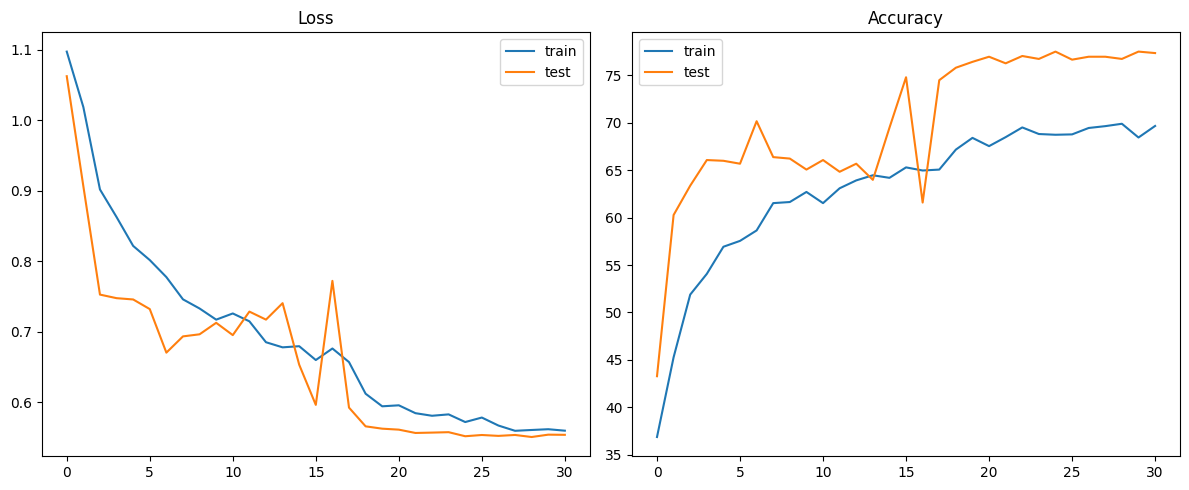

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_loss_arr, label='train')
axes[0].plot(test_loss_arr, label='test')
axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(train_accuracy_arr, label='train')
axes[1].plot(test_accuracy_arr, label='test')
axes[1].legend()
axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

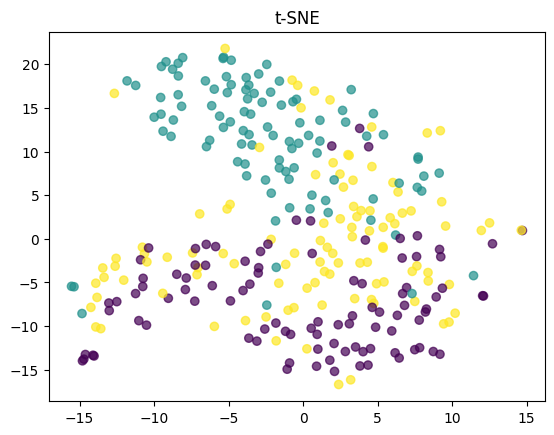

In [248]:
embeddings_arr = []
for inputs, labels in test_loader:
    inputs = inputs.unsqueeze(1)
    embeddings = model.get_embed(inputs).detach().numpy()
    embeddings_arr.extend([embedding for embedding in embeddings])
random_indices = np.random.choice(len(embeddings_arr), size=300, replace=False)
random_embeddings = np.array(embeddings_arr)[random_indices]
random_labels = np.array(y_test)[random_indices]

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(random_embeddings)

# umap = UMAP(n_components=2, random_state=42)
# data_2d = umap.fit_transform(random_embeddings)

scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=random_labels, alpha=0.7)

plt.title('t-SNE')
plt.show()

Classification Report:
              precision    recall  f1-score   support

          Sw       0.77      0.83      0.80       442
          Tg       0.83      0.89      0.86       426
          Vw       0.70      0.59      0.64       426

    accuracy                           0.77      1294
   macro avg       0.77      0.77      0.77      1294
weighted avg       0.77      0.77      0.77      1294

Precision: 0.7676, Recall: 0.7728, F1: 0.7680, ROC AUC: 0.9089


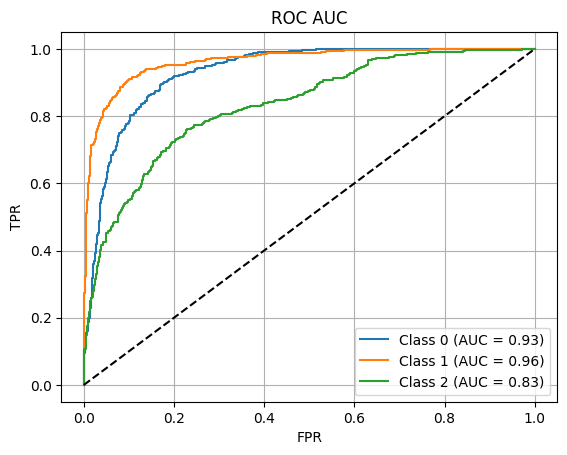

In [249]:
_, _, all_outputs, all_probs, all_labels = validate(model, criterion, test_loader)

precision = precision_score(all_labels, all_outputs, average='weighted')
recall = recall_score(all_labels, all_outputs, average='weighted')
f1 = f1_score(all_labels, all_outputs, average='weighted')

roc_auc = {}
for i in range(num_classes):
    class_targets = (all_labels == i).astype(int)
    roc_auc[i] = roc_auc_score(class_targets, all_probs[:, i])

mean_roc_auc = np.mean(list(roc_auc.values()))

print("Classification Report:")
print(classification_report(all_labels, all_outputs, target_names=label_encoder.classes_))
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC AUC: {mean_roc_auc:.4f}")

for i in range(num_classes):
    class_targets = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(class_targets, all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_score(class_targets, all_probs[:, i]):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC AUC")
plt.legend()
plt.grid()
plt.show()

